# Nighttime Lights in Myanmar

This notebook has been prepared for the Myanmar Economic Monitor (Spring 2026). It uses data from the NASA VIIRS BlackMarble dataset available from 2012 till March 2026.

**Sections:**

1. **National Nighttime Lights Trends**
   - 1.1 Annual Trends in Nightlights
   - 1.2 Quarterly Trends in Nightlights
   - 1.3 Annual % Change in Nightlights
   - 1.4 Monthly Trends in Nightlights (comparing 2024, 2025, 2026)

2. **Nightlights in Industrial Areas**
   - 2.1 Quarterly Trends in Industrial vs Non-Industrial Areas
   - 2.2 Percentage Change in Industrial vs Non-Industrial Areas
   - 2.3 Monthly Trends in Industrial Areas (comparing 2024, 2025, 2026)

3. **Nightlights in Regions**
   - 3.1 Quarterly Trends in Nightlights in Regions
   - 3.2 Monthly Trends in Nightlights in Regions (comparing 2024, 2025, 2026)
   - 3.3 Monthly Trends in Regional Industrial Areas (comparing 2024, 2025, 2026)

4. **Spatial Distribution of Nightlights**
   - 4.1 Quarterly Nightlights in Regions
   - 4.2 Quarterly Nightlights in Districts

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from pathlib import Path
import glob

In [89]:
# Import visualization functions
%load_ext autoreload
%autoreload 2  
# sys.path.append('../../../src/')
from visuals import *
from utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [90]:
DATA_FOLDER = Path("../../../data/")
NTL_FOLDER = DATA_FOLDER / "ntl" / "collection2"

from datetime import datetime

current_year = datetime.now().year
prev_year = current_year - 1
max_month = datetime.now().month - 1

In [91]:
# --- Load NTL data ---
ntl_annual_adm0 = pd.read_csv(NTL_FOLDER / "annual/ntl_mmr_adm0_annual.csv")
ntl_annual_adm1 = pd.read_csv(NTL_FOLDER / "annual/ntl_mmr_adm1_annual.csv")
ntl_monthly_adm0 = pd.read_csv(NTL_FOLDER / "monthly/ntl_mmr_adm0_monthly.csv")
ntl_monthly_adm1 = pd.read_csv(NTL_FOLDER / "monthly/ntl_mmr_adm1_monthly.csv")
ntl_monthly_adm2 = pd.read_csv(NTL_FOLDER / "monthly/ntl_mmr_adm2_monthly.csv")
ntl_annual_ind_5km = pd.read_csv(NTL_FOLDER / "annual/ntl_mmr_admsez_annual.csv")

# --- Load boundaries ---
mmr_adm0 = gpd.read_file(DATA_FOLDER / "boundaries" / "mmr_polbnda_adm0_250k_mimu_20240215.shp")
mmr_adm1 = gpd.read_file(DATA_FOLDER / "boundaries" / "mmr_polbnda_adm1_250k_mimu_20240215.shp")
mmr_adm2 = gpd.read_file(DATA_FOLDER / "boundaries" / "mmr_polbnda_adm2_250k_mimu_20240215.shp")
mmr_adm3 = gpd.read_file(DATA_FOLDER / "boundaries" / "mmr_polbnda_adm3_250k_mimu_20240215.shp")

# --- Load industrial zones ---
industrial_zones = gpd.read_file(DATA_FOLDER / "boundaries" / "industrial__special_economic_zones_sept2019.shp")
industrial_zones = industrial_zones.sjoin(
    mmr_adm3[["ADM1_PCODE", "ADM1_EN", "ADM2_EN", "ADM2_PCODE", "ADM3_EN", "ADM3_PCODE", "geometry"]]
)

In [92]:
# --- Prepare all derived datasets ---
ntl_monthly_adm0["date"] = pd.to_datetime(ntl_monthly_adm0["date"])
ntl_monthly_adm0["year_col"] = ntl_monthly_adm0["date"].dt.year
ntl_monthly_adm0["month"] = ntl_monthly_adm0["date"].dt.month

ntl_monthly_adm1["date"] = pd.to_datetime(ntl_monthly_adm1["date"])
ntl_monthly_adm1["year_col"] = ntl_monthly_adm1["date"].dt.year
ntl_monthly_adm1["month"] = ntl_monthly_adm1["date"].dt.month

# Partial-year corrected totals (Jan through max_month)
ntl_corrected = prepare_ntl_corrected(ntl_monthly_adm0, max_month)

# Annual YoY with partial-year overlay
annual_yoy = prepare_annual_yoy_with_partial(ntl_annual_adm0, ntl_corrected, "ntl_sum")
annual_ind_yoy = prepare_annual_yoy_with_partial(ntl_annual_adm0, ntl_corrected, "ntl_ind_5km_sum")
annual_noind_yoy = prepare_annual_yoy_with_partial(ntl_annual_adm0, ntl_corrected, "ntl_noind_5km_sum")

# Monthly comparison (3 years)
ntl_comparison = prepare_monthly_comparison(ntl_monthly_adm0, [prev_year - 1, prev_year, current_year])

# Industrial vs non-industrial melted
ntl_ind_melted = prepare_industrial_comparison_melted(ntl_monthly_adm0, [prev_year - 1, prev_year, current_year])

# Regional industrial data
df_regional_ind, region_order_list = prepare_regional_industrial_data(ntl_monthly_adm1)
ntl_regional_comparison = prepare_regional_comparison(ntl_monthly_adm1, [prev_year - 1, prev_year, current_year], region_order_list)

# Earthquake period data
ntl_earthquake_period = prepare_earthquake_period_data(ntl_monthly_adm1, mmr_adm1)

# Subnational monthly pct changes
monthly_pct_changes = subnational_monthly_pct_change(
    df=ntl_monthly_adm2, region_col="ADM2_EN", baseline_year=prev_year,
    current_year=current_year, date_col="date",
)
monthly_pct_changes = mmr_adm2[["ADM2_EN", "geometry"]].merge(monthly_pct_changes, on="ADM2_EN", how="inner")

## 1. National Nighttime Lights Trends

This section highlights the natiobnal change in nightlights. The last available anual dataset is for 2025. 

### 1.1 Annual Trends in Nightlights

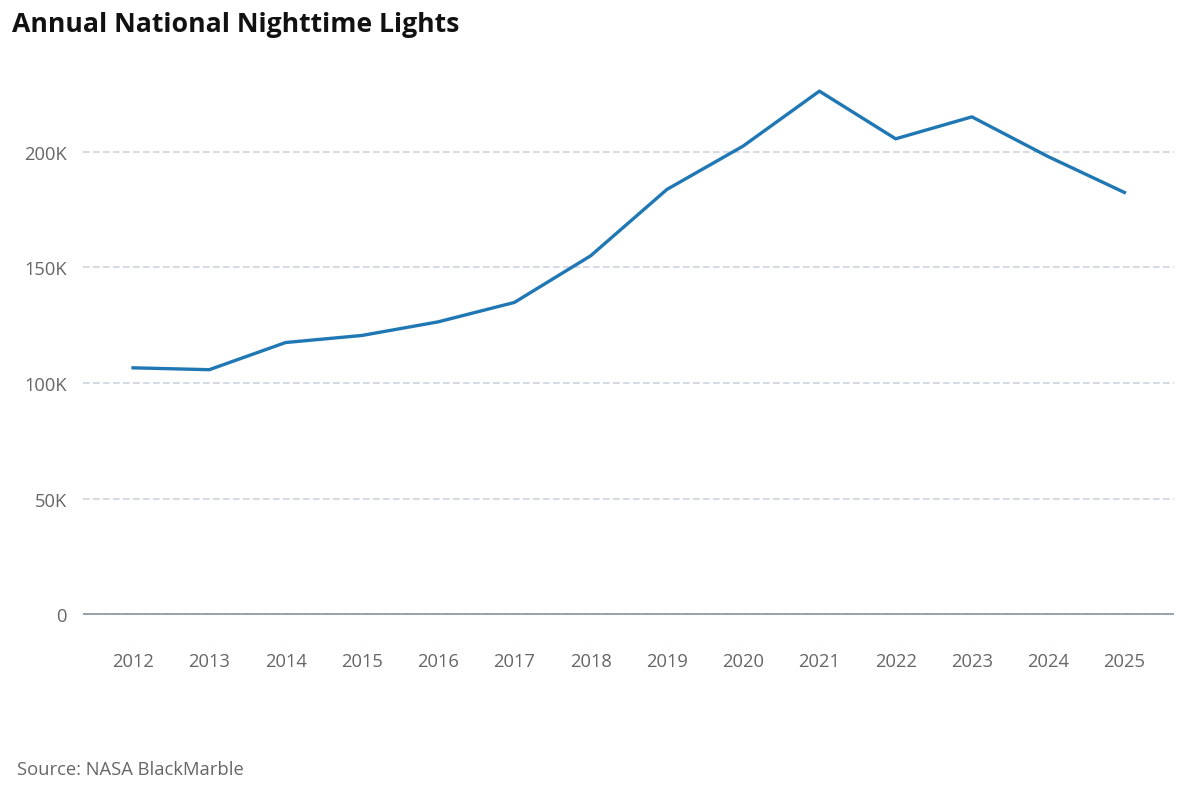

In [93]:
# Fig 1.1: Annual Trends in Nightlights
plot_line_chart(
    df=ntl_annual_adm0,
    x_col="year",
    value_col="ntl_sum",
    title="Annual National Nighttime Lights",
    source_text="Source: NASA BlackMarble",
    xlabel="Year",
    ylabel="",
    date_col="date",
    marker=None,
)

Myanmar saw an earthquake in 2025 which likely contributed to the reduction in overall nightlights. 

### 1.2 Quarterly Trends in Nightlights

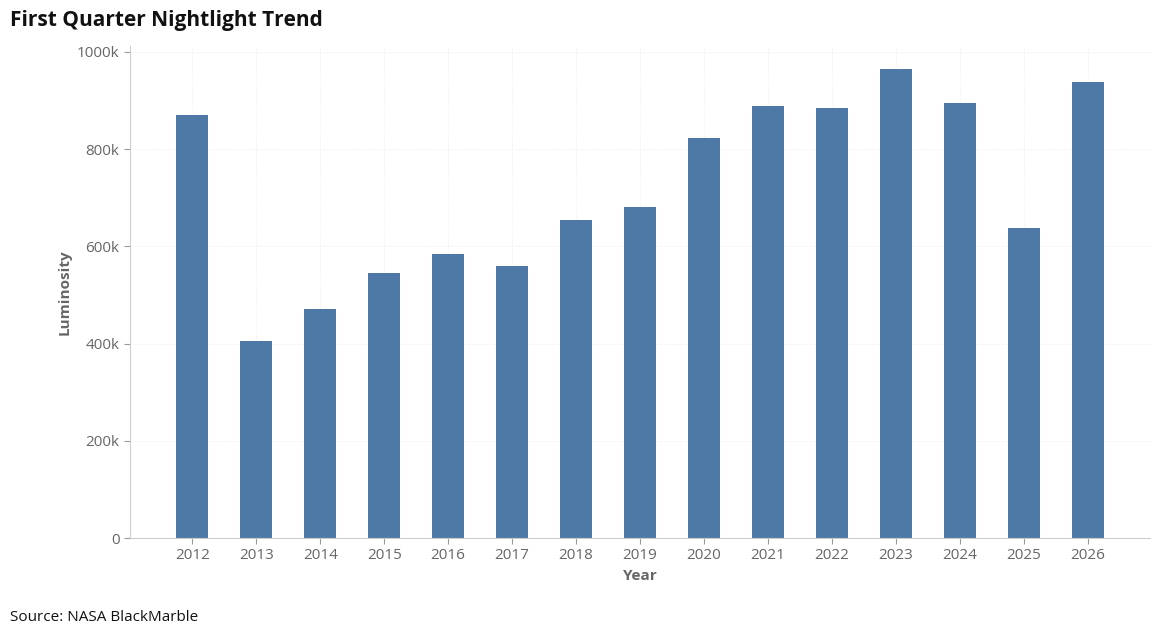

In [94]:
# Fig 1.2: Quarterly Trends in Nightlights
fig, ax = plot_bar_chart(
    df=annual_yoy,
    x_col="year",
    value_col="ntl_sum_y",
    title="First Quarter Nightlight Trend",
    xlabel="Year",
    ylabel="Luminosity",
    date_col="date",
    bar_width=0.5,
)

However, if the average lights in the period of January to March are compared, it is seen that 2026 shows signs of recovery with the second highest nightlights since 2012, closely following 2023. 

### 1.3 Annual % Change in Nightlights

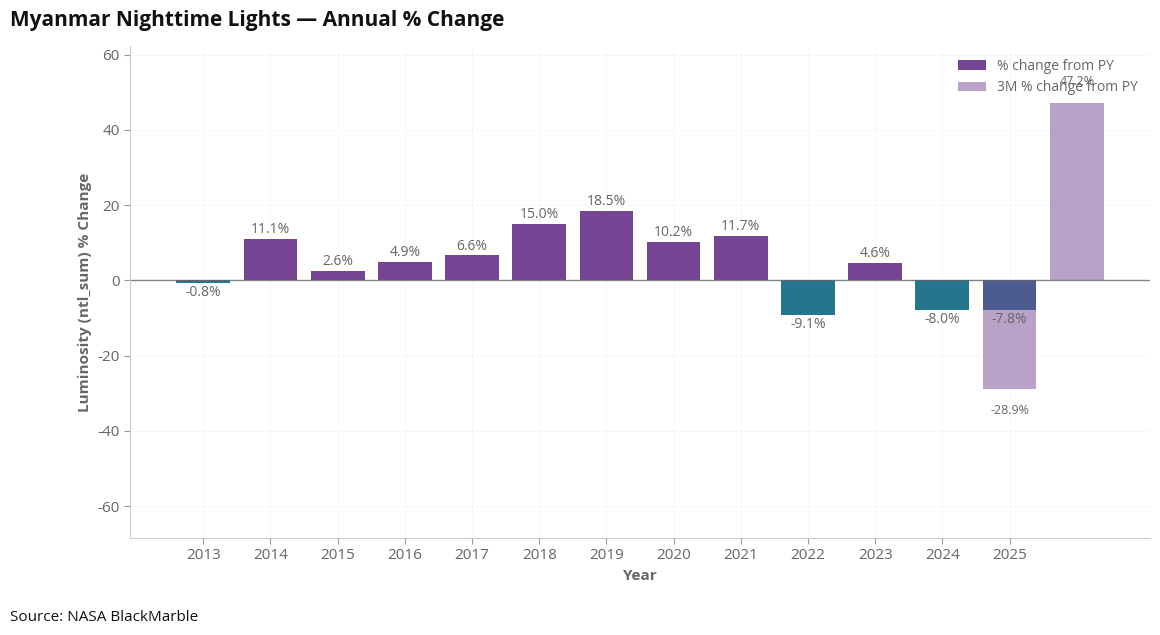

In [95]:
# Fig 1.3: Annual % Change in Nightlights
fig, ax = plot_bar_chart(
    df=annual_yoy,
    x_col="year",
    value_col="pct_change_full_year",
    title="Myanmar Nighttime Lights — Annual % Change",
    xlabel="Year",
    ylabel="Luminosity (ntl_sum) % Change",
    earthquake_marker="2025-03-25",
    date_col=None,
    bar_width=0.8,
    is_percentage=True,
)
add_partial_year_bars(ax, annual_yoy, "pct_change_full_year", "pct_change_9months", current_year, prev_year, max_month, show_legend=True)
plt.show()

2025 saw a 7.8% reduction in light compared to 2024. However, in the first quarter of 2025 (earthquake period), there was a ~29% reduction in light. In comparison, there is a 47% increase in light in 2026 compared to 2025. 

### 1.4 Monthly Trends in Nightlights (comparing 2024, 2025, 2026)

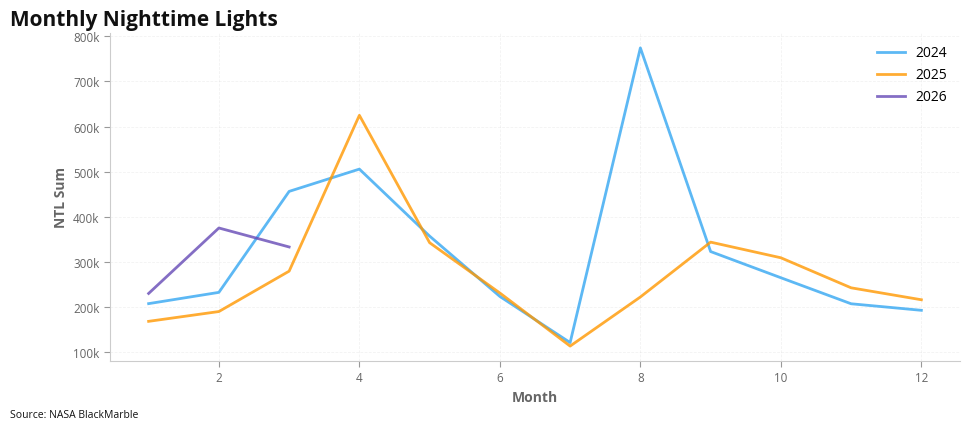

In [96]:
# Fig 1.4b: Monthly Trends - Comparative Lines (2024 vs 2025 vs 2026)
plot_comparative_lines(
    df=ntl_comparison,
    x_col="month",
    value_col="ntl_sum",
    group_col="year_col",
    title="Monthly Nighttime Lights",
    xlabel="Month",
    ylabel="NTL Sum",
    date_col="date",
    figsize=(10, 4),
    linewidth=2,
    marker_size=0,
)

The monthly nightlights in 2026 surpassed 2024 for January and February. There was a slight dip in lights in March 2026 compared to 2024. 

## 2. Nightlights in Industrial Areas

There are 97 industrial zones in Myanamr classified as Special Economic Zones. The majority are in Yangon. The analysis for nightlights in industrial zones is done by assuming a 5km buffer zone around the points. 

In [97]:
sez = gpd.read_file('../../../data/boundaries/industrial__special_economic_zones_sept2019.shp')
sez.explore()

### 2.1 Quarterly Trends in Industrial vs Non-Industrial Areas

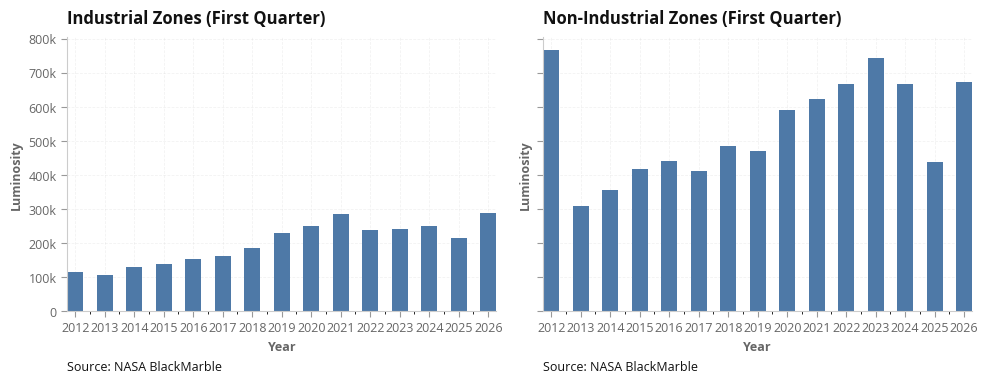

In [98]:
# Fig 2.1: Quarterly Trends in Industrial vs Non-Industrial Areas
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

plot_bar_chart(
    df=ntl_corrected,
    x_col="date",
    value_col="ntl_ind_5km_sum",
    title="Industrial Zones (First Quarter)",
    xlabel="Year",
    ylabel="Luminosity",
    date_col="date",
    bar_width=200,
    ax=axes[0],
)

plot_bar_chart(
    df=ntl_corrected,
    x_col="date",
    value_col="ntl_noind_5km_sum",
    title="Non-Industrial Zones (First Quarter)",
    xlabel="Year",
    ylabel="Luminosity",
    date_col="date",
    bar_width=200,
    ax=axes[1],
)

plt.tight_layout()
plt.show()

The nighttime lights in the first quarter of 2026 has surpassed that of 2024 for both Industrial and non industrial zones. 

### 2.2 Percentage Change in Industrial vs Non-Industrial Areas

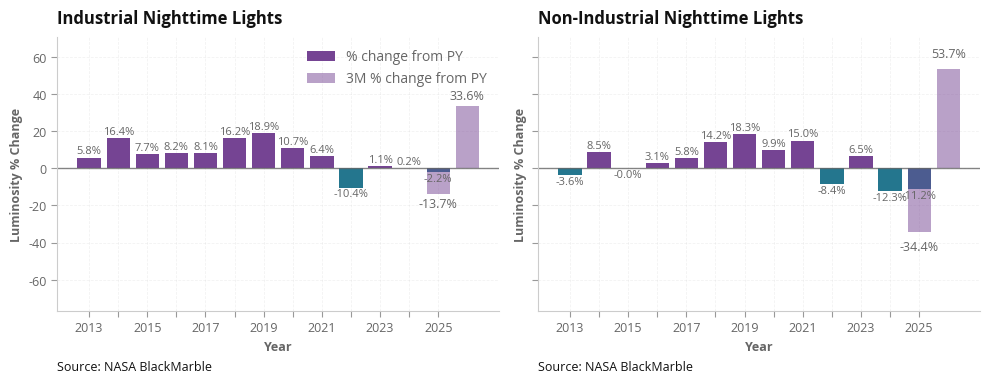

In [99]:
# Fig 2.2: Percentage Change in Industrial vs Non-Industrial Areas
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

plot_bar_chart(
    df=annual_ind_yoy,
    x_col="year",
    value_col="pct_change_full_year",
    title="Industrial Nighttime Lights",
    xlabel="Year",
    ylabel="Luminosity % Change",
    earthquake_marker="2025-03-25",
    date_col=None,
    bar_width=0.8,
    is_percentage=True,
    ax=axes[0],
)
add_partial_year_bars(axes[0], annual_ind_yoy, "pct_change_full_year", "pct_change_9months", current_year, prev_year, max_month, show_legend=True)

plot_bar_chart(
    df=annual_noind_yoy,
    x_col="year",
    value_col="pct_change_full_year",
    title="Non-Industrial Nighttime Lights",
    xlabel="Year",
    ylabel="Luminosity % Change",
    earthquake_marker="2025-03-25",
    date_col=None,
    bar_width=0.8,
    is_percentage=True,
    ax=axes[1],
)
add_partial_year_bars(axes[1], 
                      annual_noind_yoy, 
                      "pct_change_full_year", 
                      "pct_change_9months", 
                      current_year, 
                      prev_year, 
                      max_month)

plt.tight_layout()
plt.show()

Overall, in 2025, there a 2% reduction in nightlights in industrial areas and 11% reduction in non industrial areas compared to 2024. 2026 has recovered in both industrial and non industrial zones

### 2.3 Monthly Trends in Industrial Areas (comparing 2024, 2025, 2026)

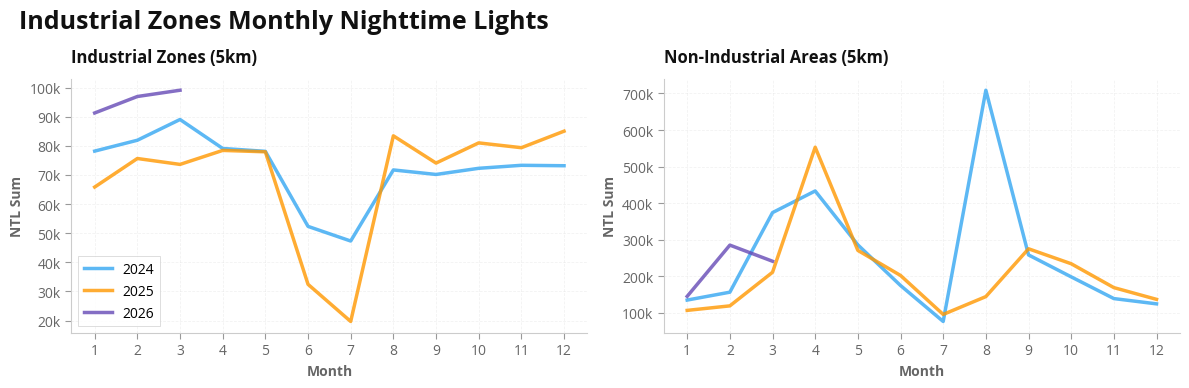

In [100]:
# Fig 2.3: Monthly Trends in Industrial Areas (comparing 2024, 2025, 2026)
plot_comparative_lines_subplots(
    df=ntl_ind_melted,
    category_col="type",
    x_col="month",
    value_col="ntl_sum",
    group_col="year_col",
    title="Industrial Zones Monthly Nighttime Lights",
    xlabel="Month",
    ylabel="NTL Sum",
    date_col="date",
    ncols=2,
    figsize_per_subplot=(6, 4),
    linewidth=2.5,
    marker_size=0,
    colors=["#34A7F2", "#FF9800", "#664AB6"],
    share_axes=False,
);

Nightlights in industrial zones in the first quarter have been higher across all months Jan-Mar in 2026 compared to 20265 and 2024. 

## 3. Nightlights in Regions

### 3.1 Quarterly Trends in Nightlights in Regions

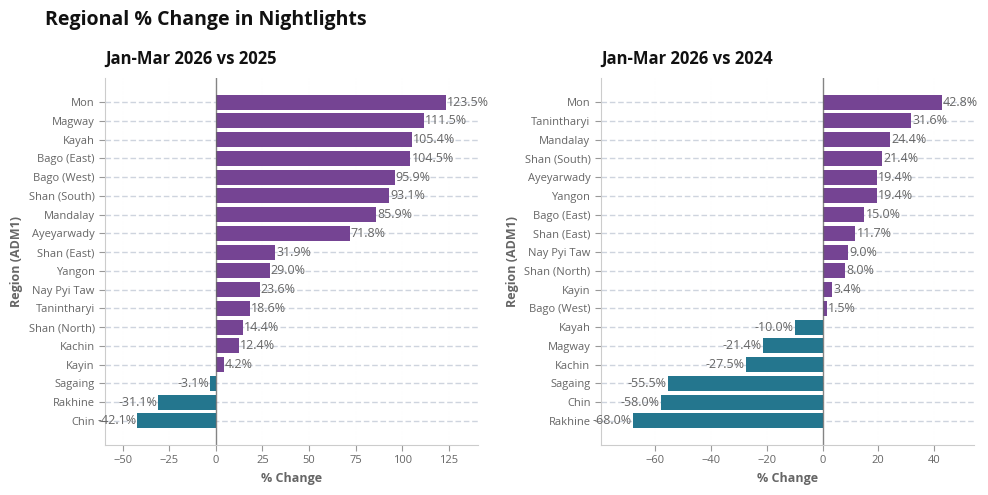

In [101]:
# Fig 3.2: Monthly Trends in Regions — Industrial vs Non-Industrial
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_regional_ntl_change(
    ntl_monthly_adm1,
    year1=prev_year,
    year2=current_year,
    max_month=3,
    value_col="ntl_sum",
    title=f"Jan-Mar {current_year} vs {prev_year}",
    figsize=(5, 8),
    ax=axes[0],
)

plot_regional_ntl_change(
    ntl_monthly_adm1,
    year1=prev_year - 1,
    year2=current_year,
    max_month=3,
    value_col="ntl_sum",
    title=f"Jan-Mar {current_year} vs {prev_year-1}",
    figsize=(5, 8),
    ax=axes[1],
)

fig.suptitle("Regional % Change in Nightlights", fontsize=14, fontweight="bold", fontfamily="Open Sans", color="#111111", ha="left", x=0.05, y=0.98)
plt.tight_layout()
plt.show()

Both Mandalay and Yangon saw ~20% increase in lights compared to 2024. 

/Users/ssarva/myanmar-economic-monitor/.venv/lib/python3.13/site-packages/matplotlib/transforms.py:352: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


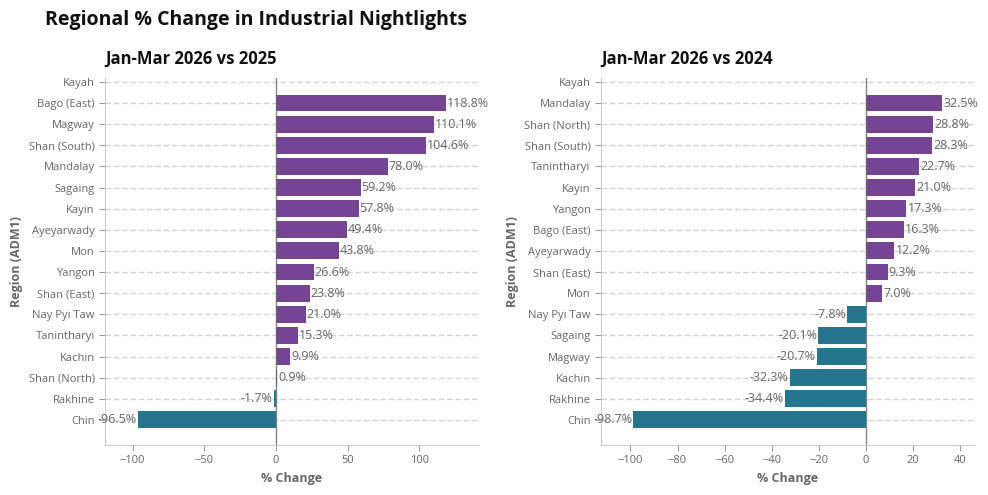

In [102]:
# Fig 3.2: Monthly Trends in Regions — Industrial vs Non-Industrial
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_regional_ntl_change(
    ntl_monthly_adm1,
    year1=prev_year,
    year2=current_year,
    max_month=3,
    value_col="ntl_ind_5km_sum",
    title=f"Jan-Mar {current_year} vs {prev_year}",
    figsize=(5, 8),
    ax=axes[0],
)

plot_regional_ntl_change(
    ntl_monthly_adm1,
    year1=prev_year - 1,
    year2=current_year,
    max_month=3,
    value_col="ntl_ind_5km_sum",
    title=f"Jan-Mar {current_year} vs {prev_year-1}",
    figsize=(5, 8),
    ax=axes[1],
)

fig.suptitle("Regional % Change in Industrial Nightlights", fontsize=14, fontweight="bold", fontfamily="Open Sans", color="#111111", ha="left", x=0.05, y=0.98)
plt.tight_layout()
plt.show();

Most areas saw an increase in nighlights in industrial areas in 2026 compared to 2025 and 2024. However, Nay Pyi Taw saw a decrease in lights in 2026 compared to 2024. 

### 3.2 Monthly Trends in Regional Industrial Areas (comparing 2024, 2025, 2026)

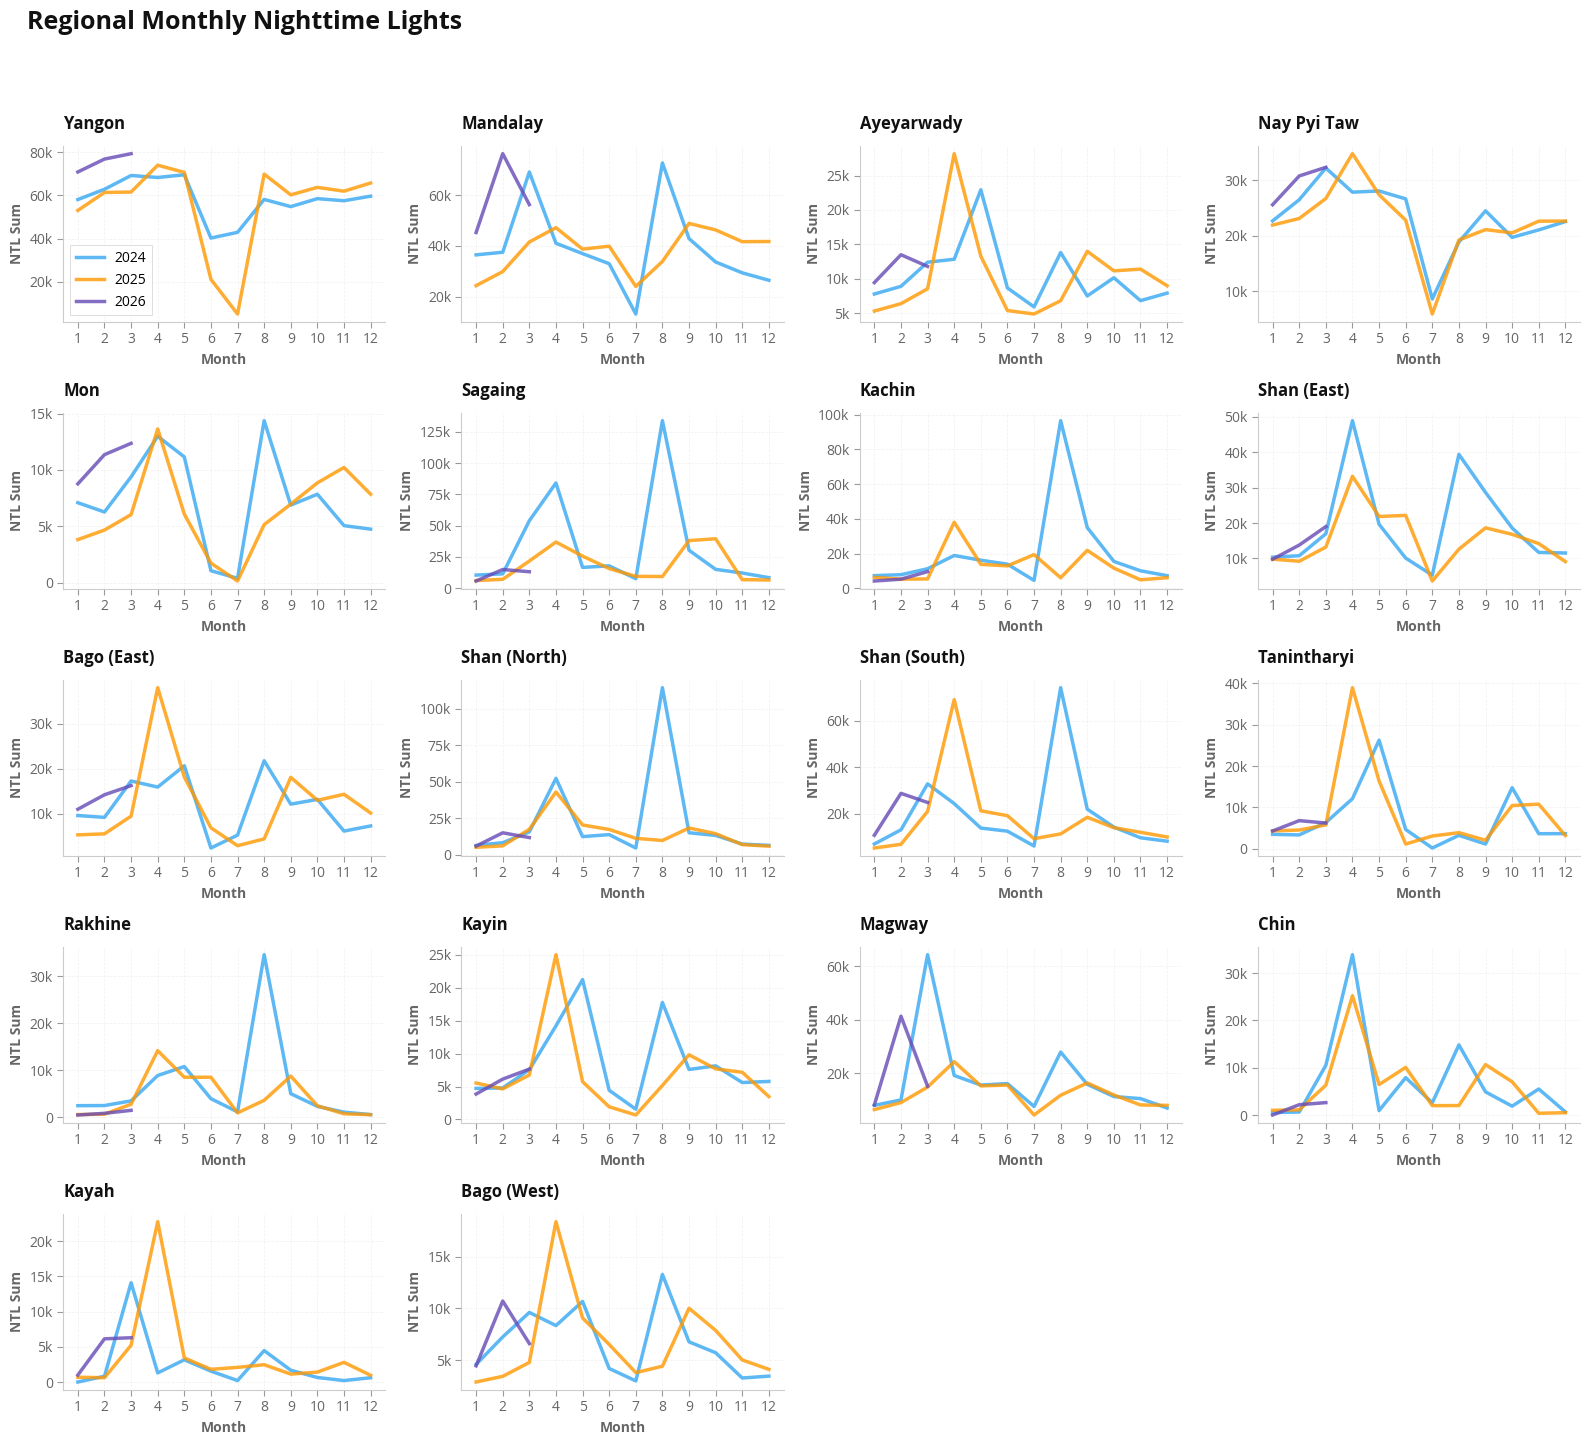

In [103]:
# Fig 3.3b: Monthly Trends in Regional Industrial Areas — Comparative Lines
plot_comparative_lines_subplots(
    df=ntl_regional_comparison,
    category_col="ADM1_EN",
    x_col="month",
    value_col="ntl_sum",
    group_col="year_col",
    title=f"Regional Monthly Nighttime Lights",
    xlabel="Month",
    ylabel="NTL Sum",
    date_col="date",
    ncols=4,
    figsize_per_subplot=(4, 3),
    linewidth=2.5,
    marker_size=0,
    colors=["#34A7F2", "#FF9800", "#664AB6"],
    share_axes=False,
);

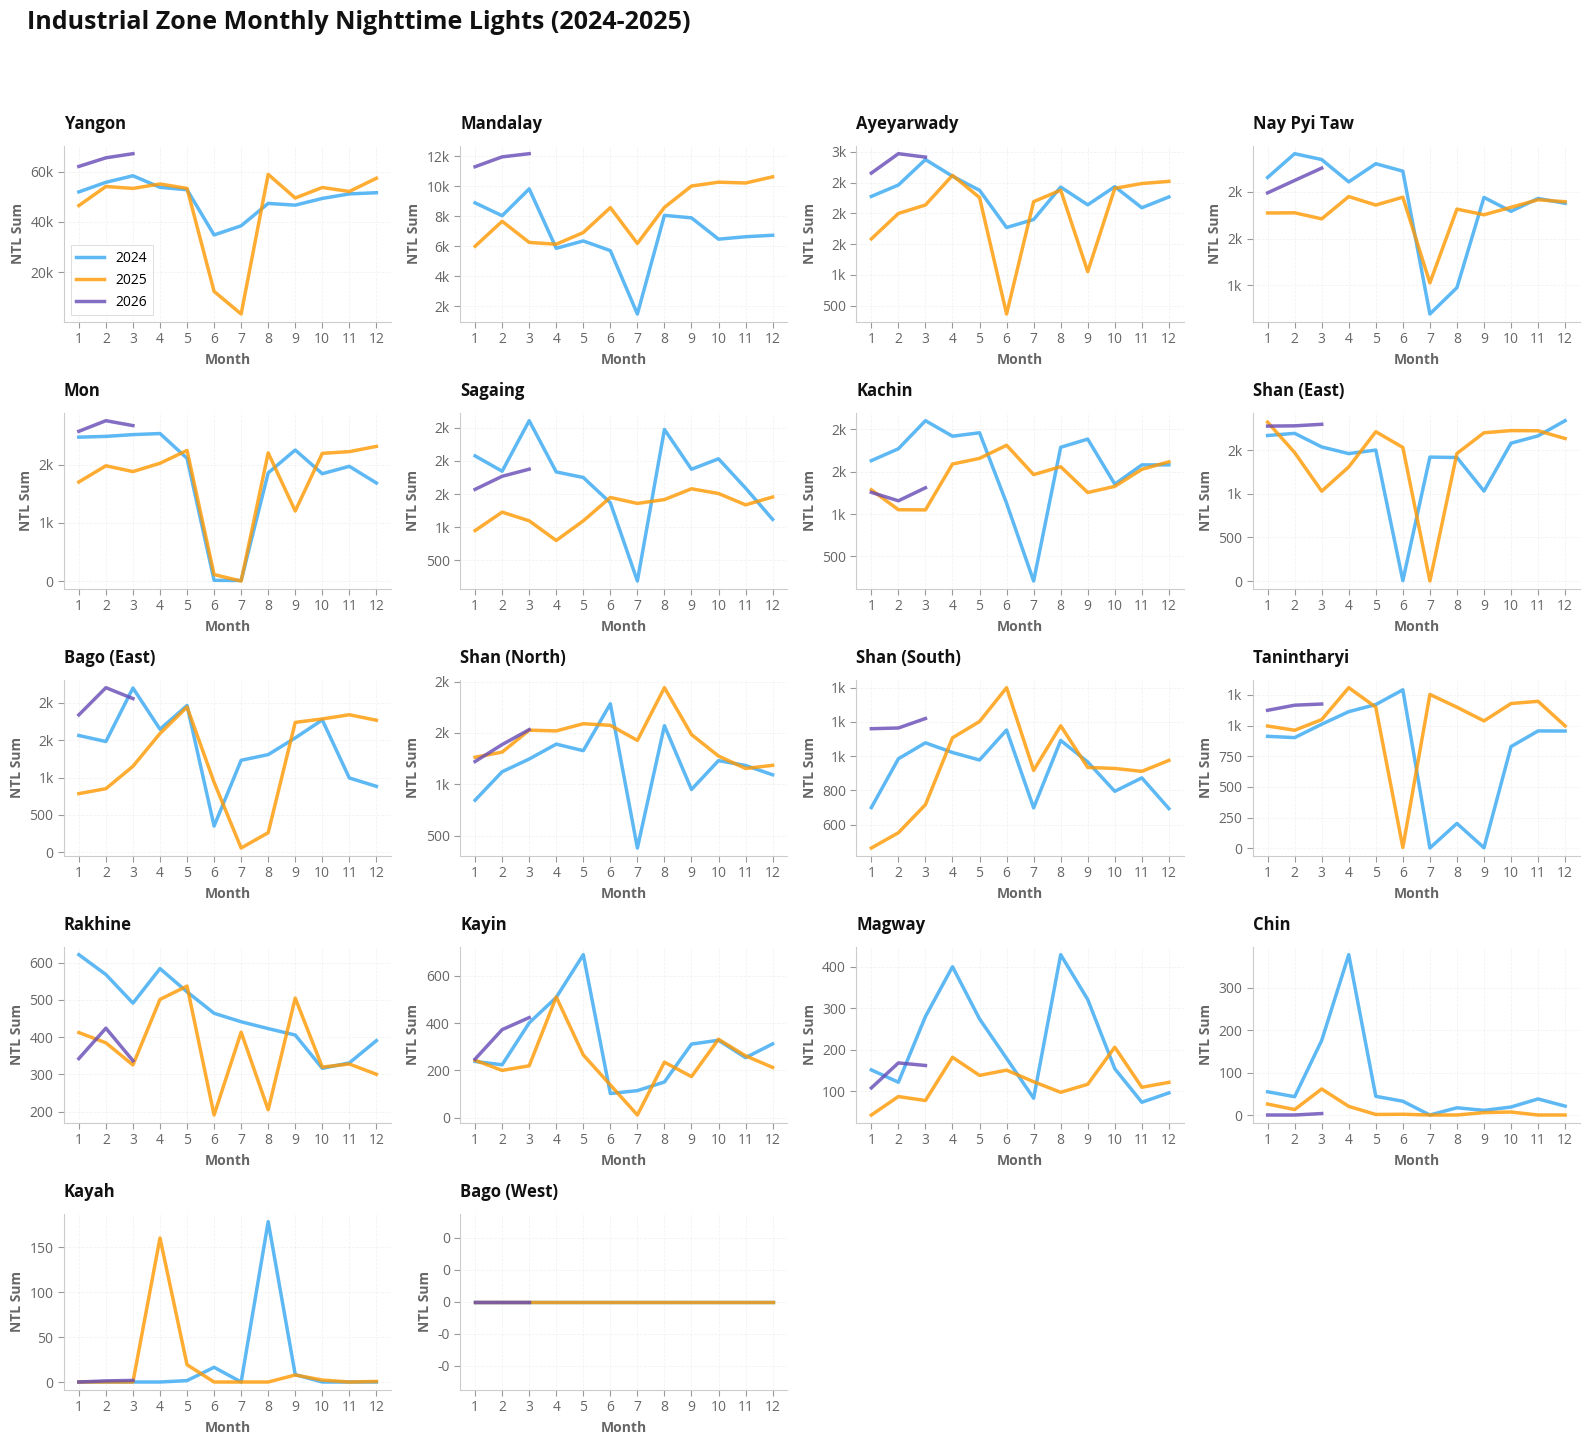

In [104]:
# Fig 3.3b: Monthly Trends in Regional Industrial Areas — Comparative Lines
plot_comparative_lines_subplots(
    df=ntl_regional_comparison,
    category_col="ADM1_EN",
    x_col="month",
    value_col="ntl_ind_5km_sum",
    group_col="year_col",
    title=f"Industrial Zone Monthly Nighttime Lights ({prev_year-1}-{prev_year})",
    xlabel="Month",
    ylabel="NTL Sum",
    date_col="date",
    ncols=4,
    figsize_per_subplot=(4, 3),
    linewidth=2.5,
    marker_size=0,
    colors=["#34A7F2", "#FF9800", "#664AB6"],
    share_axes=False,
);